In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
size = 500
image = np.zeros((size, size, 3))
cx, cy, cz = size // 2, size // 2, size // 2

In the next cell we define various classes that should help build the scene, like spatial objects that should appear in the scene and lightsources.

In [ ]:
class SpatialObject:
    def __init__(self, position, color, function, md=0.5, ms=0.5, msp=0.5, msn=0.5):
        self.position = position      # (px, py, pz)
        self.color = color            # (r, g, b)
        self.function = function      # f(x, y, z) -> scalar
        self.md = md                 # Diffuse reflection coefficient
        self.ms = ms                # Specular reflection coefficient
        self.msp = msp                # Specular exponent
        self.msn = msn                # Shininess

    def evaluate(self, points):
        """
        Evaluate the object's function at a world-space point.
        """
        p = points - self.position                  # (...,3)
        x, y, z = p[..., 0], p[..., 1], p[..., 2]   # (...)
        return self.function(x, y, z)
    
    @staticmethod
    def estimate_normal(obj, p, eps=1e-4):
        # p: (..., 3)
        ex = np.array([eps, 0, 0], dtype=float)
        ey = np.array([0, eps, 0], dtype=float)
        ez = np.array([0, 0, eps], dtype=float)

        fx = obj.evaluate(p + ex) - obj.evaluate(p - ex)
        fy = obj.evaluate(p + ey) - obj.evaluate(p - ey)
        fz = obj.evaluate(p + ez) - obj.evaluate(p - ez)

        n = np.stack([fx, fy, fz], axis=-1)              # (..., 3)
        n /= (np.linalg.norm(n, axis=-1, keepdims=True) + 1e-12)
        return n



def sphere_sdf(R):
    def f(x, y, z):
        return np.sqrt(x*x + y*y + z*z) - R
    return f
        
        
    
class Light_Source:
    def __init__(self, position, intensity, ambient_intensity):
        self.position = position
        self.intensity = intensity
        self.ambient_intensity = ambient_intensity


In [ ]:
import numpy as np

class Camera:
    def __init__(self, origin, look_at, up=(0, 1, 0), width=500, height=500, fov_degrees=60):
        self.origin = np.array(origin, dtype=float)
        self.look_at = np.array(look_at, dtype=float)
        self.up = np.array(up, dtype=float)
        self.width = int(width)
        self.height = int(height)
        self.fov = np.deg2rad(float(fov_degrees))

        self._build_basis()

    def _build_basis(self):
        # forward points from camera to target
        forward = self.look_at - self.origin
        forward /= np.linalg.norm(forward)

        # right = forward x up
        right = np.cross(forward, self.up)
        right /= np.linalg.norm(right)

        # true_up = right x forward
        true_up = np.cross(right, forward)
        true_up /= np.linalg.norm(true_up)

        self.forward = forward
        self.right = right
        self.true_up = true_up

    def ray_directions(self):
        H, W = self.height, self.width

        ys = np.arange(H, dtype=float)
        xs = np.arange(W, dtype=float)

        # pixel centers -> NDC [-1,1]
        x = (2 * (xs + 0.5) / W - 1.0)[None, :]      # (1,W)
        y = (1.0 - 2 * (ys + 0.5) / H)[:, None]      # (H,1)

        aspect = W / H
        scale = np.tan(self.fov * 0.5)

        # camera-space directions
        cx = x * aspect * scale                       # (H,W)
        cy = y * scale                                # (H,W)

        # world-space directions (broadcasted)
        rd = (
            self.forward[None, None, :] +
            cx[..., None] * self.right[None, None, :] +
            cy[..., None] * self.true_up[None, None, :]
        )

        # normalize
        rd /= np.linalg.norm(rd, axis=-1, keepdims=True)
        return rd
        

def compute_phong_lighting(point, normal, light, object_color, camera_pos):
    # Ambient
    ambient = light.ambient_intensity * object_color

    # Diffuse
    light_dir = np.array(light.position) - point
    light_dir /= np.linalg.norm(light_dir)
    diff = max(np.dot(normal, light_dir), 0)
    diffuse = light.intensity * diff * object_color

    # Specular
    view_dir = np.array(camera_pos) - point
    view_dir /= np.linalg.norm(view_dir)
    reflect_dir = 2 * np.dot(normal, light_dir) * normal - light_dir
    spec = max(np.dot(view_dir, reflect_dir), 0) ** object.msp
    specular = light.intensity * spec * object.ms

    return ambient + diffuse + specular

import numpy as np

def ray_root_hits(camera, objects, dt=0.05, max_steps=400, max_dist=20.0,
                  n_refine=10):
    """
    Root finding for implicit surfaces: F(o + d t)=0
    Uses: bracket (sign change) + bisection.
    Vectorized over pixels; loops only over steps/refinement iterations.
    """
    H, W = camera.height, camera.width
    ro = np.array(camera.origin, dtype=float)[None, None, :]   # (1,1,3)
    rd = camera.ray_directions()                                # (H,W,3)

    # We’ll return the nearest hit among all objects
    hit_any = np.zeros((H, W), dtype=bool)
    t_best  = np.full((H, W), np.inf, dtype=float)
    obj_best = np.full((H, W), -1, dtype=int)

    for oi, obj in enumerate(objects):
        # marching/bracketing state for this object
        t0 = np.zeros((H, W), dtype=float)
        p0 = ro + rd * t0[..., None]
        f0 = obj.evaluate(p0)

        bracketed = np.zeros((H, W), dtype=bool)
        t1 = t0.copy()
        f1 = f0.copy()

        active = np.ones((H, W), dtype=bool)

        # --- Bracket: find sign change ---
        for _ in range(max_steps):
            # stop if all done
            if not active.any():
                break

            t1 = t0 + dt
            p1 = ro + rd * t1[..., None]
            f1 = obj.evaluate(p1)

            # sign change => bracketed root between t0 and t1
            sc = (f0 * f1) < 0
            new_brackets = active & sc & (~bracketed)

            bracketed |= new_brackets
            active &= ~new_brackets

            # advance for still-active rays
            t0 = np.where(active, t1, t0)
            f0 = np.where(active, f1, f0)

            # kill rays that go too far
            active &= (t0 < max_dist)

        # --- Refine with bisection ---
        # Only refine pixels that bracketed
        if bracketed.any():
            a = t0.copy()
            b = t1.copy()
            fa = obj.evaluate(ro + rd * a[..., None])
            fb = obj.evaluate(ro + rd * b[..., None])

            # bisection iterations
            for _ in range(n_refine):
                m = 0.5 * (a + b)
                fm = obj.evaluate(ro + rd * m[..., None])

                left = (fa * fm) < 0
                # root in [a,m] if sign change there, else in [m,b]
                b = np.where(left, m, b)
                fb = np.where(left, fm, fb)
                a = np.where(left, a, m)
                fa = np.where(left, fa, fm)

            t_hit = 0.5 * (a + b)

            # keep nearest hit across objects
            nearer = bracketed & (t_hit < t_best)
            t_best = np.where(nearer, t_hit, t_best)
            obj_best = np.where(nearer, oi, obj_best)
            hit_any |= bracketed

    # Final hit points
    p_hit = ro + rd * t_best[..., None]
    return rd, hit_any, obj_best, p_hit, t_best




def shade_4_passes(camera, objects, light, rd, hit, hit_obj, p_hit, background=(0,0,0)):
    """
    Produces 4 images: ambient-only, diffuse-only, specular-only, total.
    IMPORTANT: All lighting vectors/normals are computed ONLY on hit pixels to avoid NaNs.
    """
    H, W = camera.height, camera.width
    bg = np.array(background, dtype=float)

    ambient_img  = np.zeros((H, W, 3), dtype=float); ambient_img[:]  = bg
    diffuse_img  = np.zeros((H, W, 3), dtype=float); diffuse_img[:]  = bg
    specular_img = np.zeros((H, W, 3), dtype=float); specular_img[:] = bg
    total_img    = np.zeros((H, W, 3), dtype=float); total_img[:]    = bg

    light_pos = np.array(light.position, dtype=float)[None, :]  # (1,3)

    for i, obj in enumerate(objects):
        m = (hit_obj == i)
        if not np.any(m):
            continue

        # Gather hit points / directions for this object only
        P = p_hit[m]               # (N,3)
        V = -rd[m]                 # (N,3) view dir (from point to camera)
        V /= (np.linalg.norm(V, axis=-1, keepdims=True) + 1e-12)

        # Robust normals (finite-diff on implicit F)
        N = estimate_normal(obj, P, eps=5e-4)  # larger eps helps quartics

        # Flip normals toward the camera so N·V >= 0 (important for implicit surfaces)
        flip = (np.sum(N * V, axis=-1) < 0)
        N[flip] *= -1

        # Light direction
        L = light_pos - P
        L /= (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-12)

        color = np.array(obj.color, dtype=float)[None, :]  # (1,3)

        # Ambient (constant)
        ambient = float(light.ambient_intensity) * color   # (1,3)

        # Diffuse
        ndotl = np.clip(np.sum(N * L, axis=-1), 0.0, 1.0)  # (N,)
        diffuse = (obj.md * light.intensity) * ndotl[:, None] * color  # (N,3)

        # Specular (Blinn-Phong half-vector)
        Hvec = L + V
        Hvec /= (np.linalg.norm(Hvec, axis=-1, keepdims=True) + 1e-12)
        ndoth = np.clip(np.sum(N * Hvec, axis=-1), 0.0, 1.0)  # (N,)
        spec  = (obj.ms * light.intensity) * (ndoth ** float(obj.msp))  # (N,)
        specular = spec[:, None] * np.ones((1,3), dtype=float)          # (N,3)

        total = ambient + diffuse + specular

        # Write back
        ambient_img[m]  = ambient
        diffuse_img[m]  = diffuse
        specular_img[m] = specular
        total_img[m]    = total

    return (
        np.clip(ambient_img,  0, 1),
        np.clip(diffuse_img,  0, 1),
        np.clip(specular_img, 0, 1),
        np.clip(total_img,    0, 1),
    )



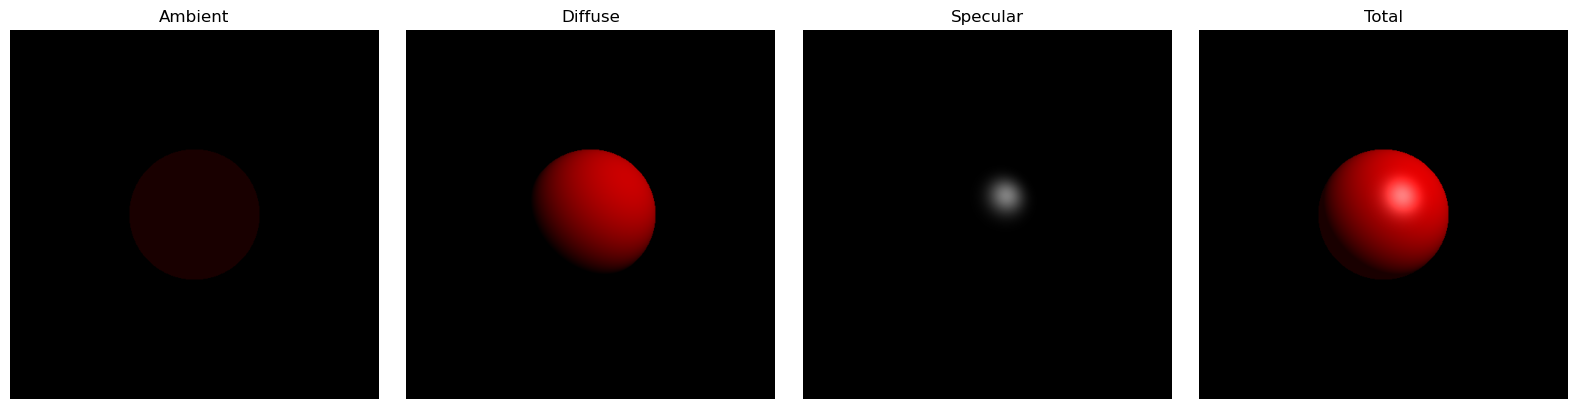

In [10]:
import matplotlib.pyplot as plt

size = 500
camera = Camera(origin=(0, 0, 0), look_at=(0, 0, -1), width=size, height=size, fov_degrees=60)
light  = Light_Source(position=(10, 10, 10), intensity=1.0, ambient_intensity=0.1)

sphere = SpatialObject(
    position=(0, 0, -5),
    color=(1, 0, 0),
    function=sphere_sdf(1.0),
    md=0.8,
    ms=0.5,
    msp=32,
    msn=0.5
)

objects = [sphere]

rd, hit, hit_obj, p_hit, t_hit = ray_root_hits(camera, objects, dt=0.02, max_dist=50.0, n_refine=12)
A, D, S, T = shade_4_passes(camera, objects, light, rd, hit, hit_obj, p_hit, background=(0,0,0))

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(A); ax[0].set_title("Ambient")
ax[1].imshow(D); ax[1].set_title("Diffuse")
ax[2].imshow(S); ax[2].set_title("Specular")
ax[3].imshow(T); ax[3].set_title("Total")
for a in ax: a.axis("off")
plt.tight_layout()
plt.show()

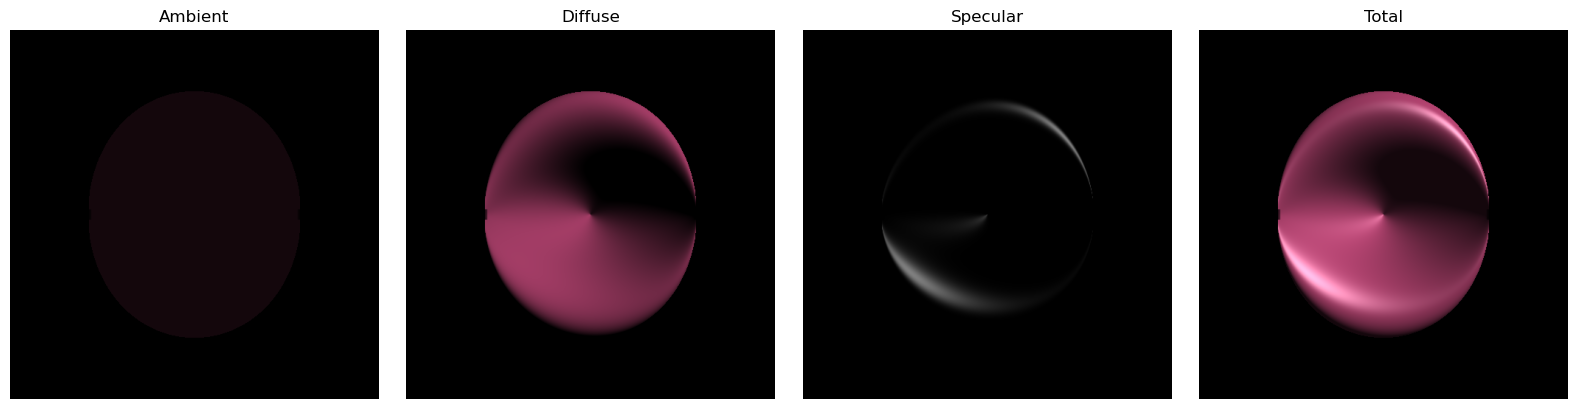

In [11]:
import matplotlib.pyplot as plt
import numpy as np

size = 500
camera = Camera(origin=(0, 0, 0), look_at=(0, 0, -1), width=size, height=size, fov_degrees=60)
light  = Light_Source(position=(10, 10, 10), intensity=1.0, ambient_intensity=0.1)

def sphere_F(R):
    def f(x,y,z):
        return x*x + y*y + z*z - R*R
    return f

def cushion_F(x, y, z):
    return (
        z**2*x**2 - z**4 - 2*z*x**2 + 2*z**3 + x**2 - z**2
        - (x**2 - z)**2
        - y**4 - 2*x**2*y**2 - y**2*z**2 + 2*y**2*z + y**2
    )

sphere = SpatialObject(position=(0, 0, -5), color=(1, 0, 0), function=sphere_F(1.0), md=0.8, ms=0.5, msp=32, msn=0.5)
cushion = SpatialObject(position=(0, 0, -4), color=(0.8, 0.3, 0.5), function=cushion_F, md=0.8, ms=0.5, msp=32, msn=0.5)

objects = [cushion]

rd, hit, hit_obj, p_hit, t_hit = ray_root_hits(camera, objects, dt=0.02, max_dist=50.0, n_refine=12)
A, D, S, T = shade_4_passes(camera, objects, light, rd, hit, hit_obj, p_hit, background=(0,0,0))

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a, img, title in zip(ax, [A,D,S,T], ["Ambient","Diffuse","Specular","Total"]):
    a.imshow(img); a.set_title(title); a.axis("off")
plt.tight_layout()
plt.show()

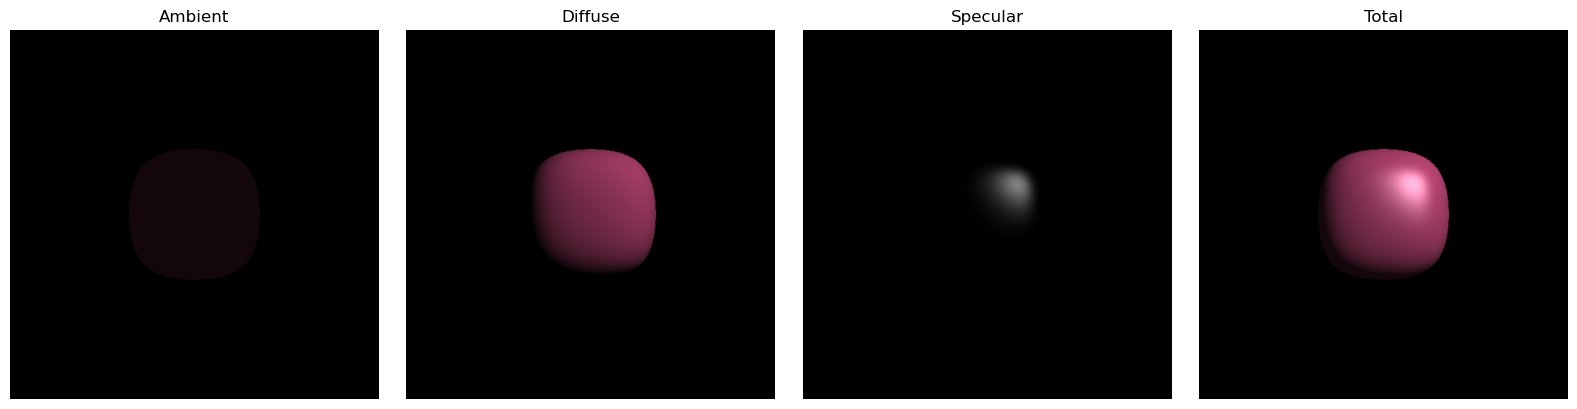

In [12]:
#Goursat surface
#x^4 + y^4 + z^4 + a*(x^2 + y^2 + z^2)^2 + b*(x^2 + y^2 + z^2) +c = 0, with a=1, b=0, c=-1
#and/or a=0, b=-2,c=-1 (nice) 
# a=0, b=-1, c=0.5
def goursat_F_1(x, y, z):
    return (
        x**4 + y**4 + z**4 + 1*(x**2 + y**2 + z**2) -1
    )

def goursat_F_2(x, y, z):
    return (
        x**4 + y**4 + z**4 - 2*(x**2 + y**2 + z**2) -1
    )

def goursat_F_3(x, y, z):
    return (
        x**4 + y**4 + z**4 - 1*(x**2 + y**2 + z**2) + 0.5
    )

goursat1 = SpatialObject(position=(0, 0, -4), color=(0.8, 0.3, 0.5), function=goursat_F_1, md=0.8, ms=0.5, msp=32, msn=0.5)
goursat2 = SpatialObject(position=(0, 0, -7), color=(0.3, 0.8, 0.5), function=goursat_F_2, md=0.8, ms=0.5, msp=32, msn=0.5)
goursat3 = SpatialObject(position=(0, 0, -7), color=(0.5, 0.3, 0.8), function=goursat_F_3, md=0.8, ms=0.5, msp=32, msn=0.5)


objects = [goursat1]
rd, hit, hit_obj, p_hit, t_hit = ray_root_hits(camera, objects, dt=0.02, max_dist=50.0, n_refine=12)
A, D, S, T = shade_4_passes(camera, objects, light, rd, hit, hit_obj, p_hit, background=(0,0,0))

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a, img, title in zip(ax, [A,D,S,T], ["Ambient","Diffuse","Specular","Total"]):
    a.imshow(img); a.set_title(title); a.axis("off")
plt.tight_layout()
plt.show()


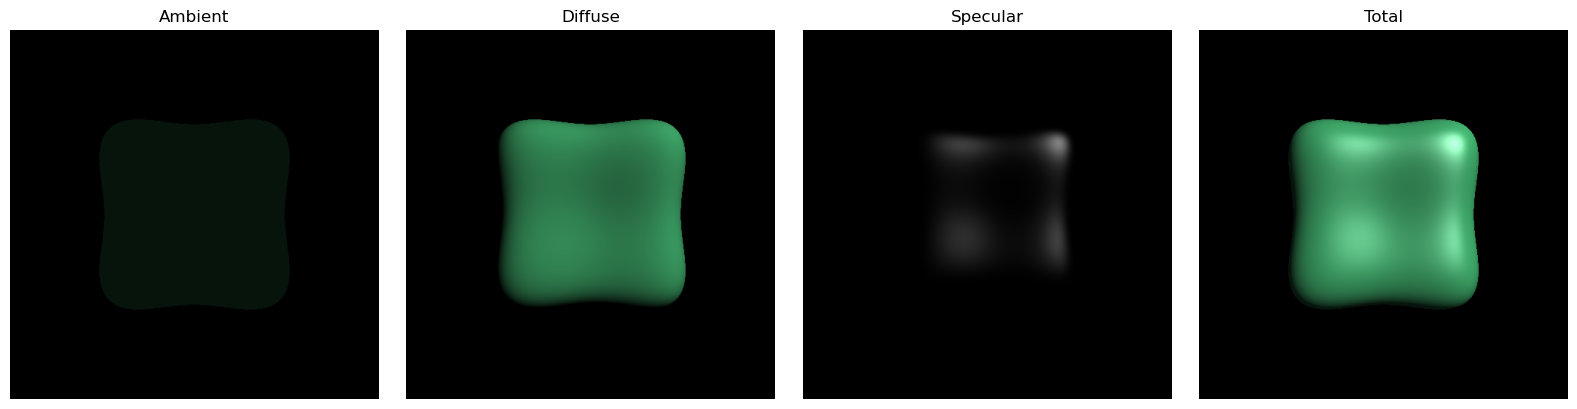

In [13]:
objects = [goursat2]

rd, hit, hit_obj, p_hit, t_hit = ray_root_hits(camera, objects, dt=0.02, max_dist=50.0, n_refine=12)
A, D, S, T = shade_4_passes(camera, objects, light, rd, hit, hit_obj, p_hit, background=(0,0,0))

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a, img, title in zip(ax, [A,D,S,T], ["Ambient","Diffuse","Specular","Total"]):
    a.imshow(img); a.set_title(title); a.axis("off")
plt.tight_layout()
plt.show()

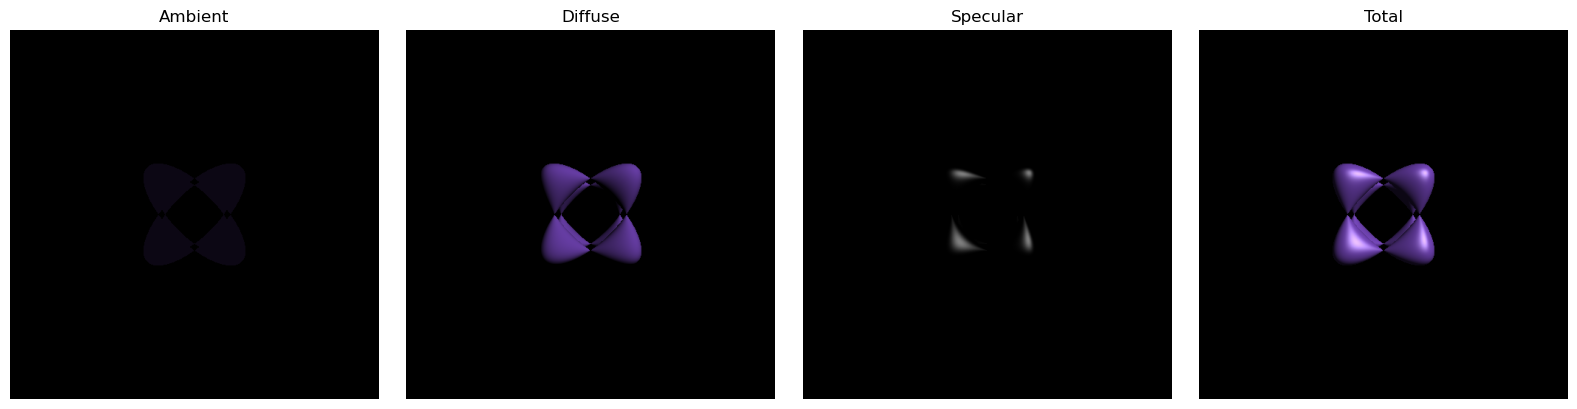

In [14]:
objects = [goursat3]
rd, hit, hit_obj, p_hit, t_hit = ray_root_hits(camera, objects, dt=0.02, max_dist=50.0, n_refine=12)
A, D, S, T = shade_4_passes(camera, objects, light, rd, hit, hit_obj, p_hit, background=(0,0,0))

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a, img, title in zip(ax, [A,D,S,T], ["Ambient","Diffuse","Specular","Total"]):
    a.imshow(img); a.set_title(title); a.axis("off")
plt.tight_layout()
plt.show()

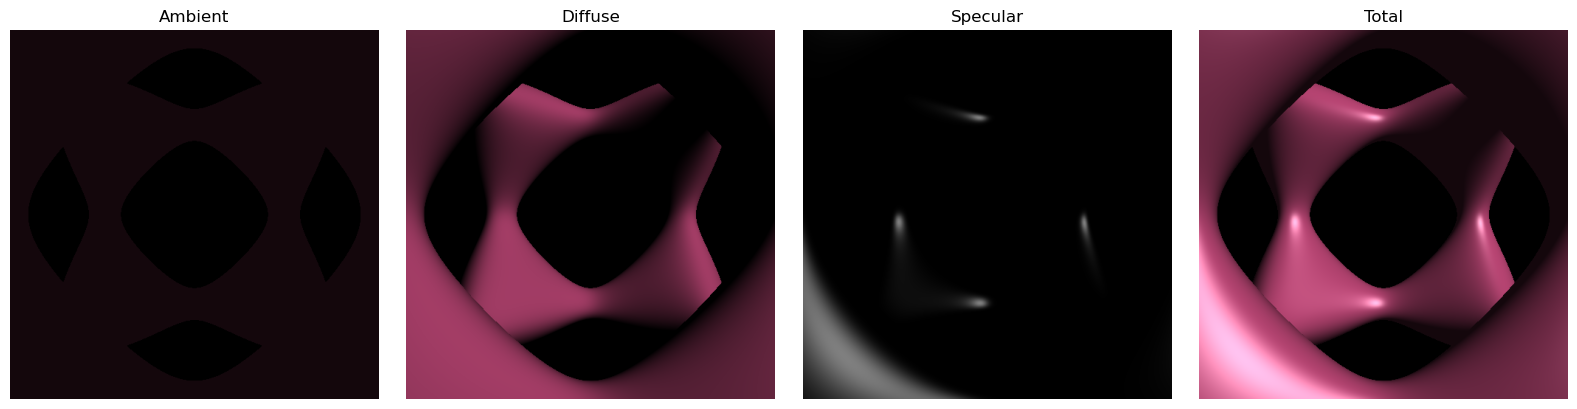

In [15]:
#Tanglecube

def tanglecube_F(x, y, z):
    return (
        x**4 - 5*x**2 + y**4 - 5*y**2 + z**4 - 5*z**2 + 11.8
    )

tangle = SpatialObject(position=(0, 0, -4), color=(0.8, 0.3, 0.5), function=tanglecube_F, md=0.8, ms=0.5, msp=32, msn=0.5)

objects = [tangle]

rd, hit, hit_obj, p_hit, t_hit = ray_root_hits(camera, objects, dt=0.02, max_dist=50.0, n_refine=12)
A, D, S, T = shade_4_passes(camera, objects, light, rd, hit, hit_obj, p_hit, background=(0,0,0))

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a, img, title in zip(ax, [A,D,S,T], ["Ambient","Diffuse","Specular","Total"]):
    a.imshow(img); a.set_title(title); a.axis("off")
plt.tight_layout()
plt.show()